<H1>Naive Bayes Classifier for Newsgroups Data Using TensorFlow Probability</H1>

This notebook demonstrates how to classify newsgroups article $X_{i}$ into one of the categories $C_{i}=c_{k},0\le k\le$ # classes.

$\text{Let }m\text{ be the number of words in a dictionary.}$<br>
$\text{Let }n\text{ be the number of possible classes.}$<br>


$\text{Let }X_{i}\text{ be a random vector }\left[x_{0}, x_{1}, ..., x_{m}\right]\text{ representing a sequence of words (i.e. tokens) present in the article.}$<br>
$\text{Let }C_{i}\text{ be a random variable denoting the class identity of some article }x_{i}\text{ where }C_{i}=c_{k}\text{ and }k\in\left[0, 1, ..., n\right]$<br>


We can use Bayes Rule to compute the posterior probability of a newsgroup article $X=x_{i}$ belonging to category $C=c_{k}$<br> 

$$\large\quad\text{Posterior}=\frac{\text{likelihood x prior}}{\text{evidence}}$$

$$\large P(C=c_{k}|X=x)=\frac{P(X=x|C=c_{k})P(C=c_{k})}{P(X=x)}$$

The denominator $P(X=x)$ is constant since this quantity is computed from the data, therefore we can estimate the posterior $P(C=c_{k}|X=x)$ using only the numerator.

$$\large P(C=c_{k}|X=x)\propto P(X=x|C=c_{k})P(C=c_{k})$$


Naive Bayes classifies an article $X_{i}=x$ to belong to category $C_{k}$ by finding the maximum a posteriori probability  of a newsgroup article $X=x_{i}$ belonging to category $C_{i}=C_{k}$.<br>

$\text{Decision Rule: Document }X_{i}=x_{i}\text{ belongs to class }C_{i}=c_{k}\text{ which maximizes the a posteriori probability of an article text }X_{i}=x_{i}$ belonging to category $C_{i}=c_{k}$<br>

$$\large \underset{MAP}{c}=P(C_{i}=c_{k}|X_{i}=x_{i})\propto \underset{k}{\mathrm{argmax}}P(X_{i}=x_{i}|C_{i}=c_{k})P(C_{i}=c_{k})$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np


In [2]:
import tensorflow as tf
import tensorflow_probability as tfp


2025-08-12 22:41:35.048931: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-12 22:41:35.061555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755038495.074937  218353 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755038495.079696  218353 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755038495.091043  218353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import f1_score

<H1>1) Fetch and preprocess the data</H1>

In [4]:
# Making a function get_data which:
#   1) Fetches the 20 newsgroup dataset
#   2) Performs a word count on the articles and binarizes the result
#   3) Returns the data as a numpy matrix with the labels

def get_data(categories):
    # Fetch the 20 newsgroup training data set
    newsgroups_train_data = fetch_20newsgroups(data_home='20_Newsgroup_Data/', subset='train', categories=categories)
    # Fetch the 20 newsgroup test data set
    newsgroups_test_data = fetch_20newsgroups(data_home='20_Newsgroup_Data/',  subset='test', categories=categories)
    # Save the number of documents (i.e. articles) in the training set
    n_documents = len(newsgroups_train_data['data'])
    # Create a CountVectorizer object to perform a binary word count
    count_vectorizer = CountVectorizer(input='content', binary=True, max_df=0.25, min_df=1.01/n_documents) 
    # Binarize the presence (1) or absence (0) of words in the articles in the training set
    train_binary_bag_of_words = count_vectorizer.fit_transform(newsgroups_train_data['data'])
    print(f'Type(train_binary_bag_of_words): {type(train_binary_bag_of_words)}')
    # Binarize the presence (1) or absence (0) of words in the articles for the test set 
    test_binary_bag_of_words = count_vectorizer.transform(newsgroups_test_data['data']) 

    return (train_binary_bag_of_words.todense(), newsgroups_train_data['target']),  (test_binary_bag_of_words.todense(), newsgroups_test_data['target']), n_documents


$\large\quad\text{Set the categories of interest and fetch/pre-process the training and test data and labels.}$<br>

In [5]:
# The 20 categories of newgroups we have in the training data are as follows:
categories = ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

# Get the newsgroup training and test data for the categories above
(train_data, train_labels), (test_data, test_labels), num_training_documents = get_data(categories)


Type(train_binary_bag_of_words): <class 'scipy.sparse._csr.csr_matrix'>


In [6]:
# Defining a function to conduct laplace smoothing. This adds a base level of probability for a given feature
# to occur in every class.

def laplace_smoothing(labels, binary_data, n_classes):
    # Compute the parameter estimates (adjusted fraction of documents in class that contain word)
    n_words = binary_data.shape[1]
    alpha = 1 # parameters for Laplace smoothing
    theta = np.zeros([n_classes, n_words]) # stores parameter values - prob. word given class
    for c_k in range(n_classes): # 0, 1, ..., 19
        class_mask = (labels == c_k)
        N = np.sum(class_mask) # number of articles in class
        theta[c_k, :] = (binary_data[class_mask, :].sum(axis=0) + alpha)/(N + alpha*2)

    return theta

$\large\text{Smooth the counts to avoid divide by zero exceptions}$<br>

In [7]:
# The binary bag of words is a 1/0 representation of whether a word occurs in a document or not
# 0's create a problem when dividing by zero so...
# Smooth the counts of the training data using Laplace smoothing to avoid division by zero
smoothed_counts = laplace_smoothing(labels=train_labels, binary_data=train_data, n_classes=len(categories))


<H1>2) Create, train and test the Naive Bayes Classifier</H1>

$\large\text{Use the smoothed counts to generate a multi-variate Bernoulli}$<br>

In [8]:
# Create a Bernoulli distribution of having batch_shape=number of classes and event_shape=number of features.
def make_distributions(probs):
    batch_of_bernoullis = tfp.distributions.Bernoulli(probs=probs) # shape (n_classes, n_words)
    dist = tfp.distributions.Independent(batch_of_bernoullis, reinterpreted_batch_ndims=1)
    return dist

In [9]:
# Use the smoothed counts to parameterize the multi-variate Bernoulli  
tf_dist = make_distributions(smoothed_counts)

I0000 00:00:1755038503.275148  218353 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10393 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:02:00.0, compute capability: 8.6


$\large\text{Compute the prior }P(C=c_{k})$<br>
$P(C=c_{k})=\frac{\text{\# Occurences }c_{k}}{\text{\# Training Samples}}$<br>

In [10]:
# Function which computes the prior probability of every class based on frequency its occurence in the training dataset
def class_priors(n_classes, labels):
    # Create an empty array of zeros, one for each class
    #counts = np.zeros(n_classes, dtype=np.double)
    counts = np.zeros(n_classes)
    # Count and store the number of occurences of class c_k
    #class_counts = tf.math.bincount(labels, minlength=n_classes, maxlength=n_classes, dtype=tf.float32)
    # Loop over each class
    for c_k in range(n_classes):
        counts[c_k] = np.sum(np.where(labels==c_k, 1, 0))    # The prior for each class c_k is simply (# c_k occurences / total number of occurences)
    priors = counts / np.sum(counts)
    print(f'Type(priors): {type(priors)}')
    print('The class priors are {}'.format(priors))
    return priors

In [11]:
# Compute the class priors 
priors = class_priors(n_classes=len(categories), labels=train_labels)


Type(priors): <class 'numpy.ndarray'>
The class priors are [0.04242531 0.05161747 0.05223617 0.05214778 0.05108715 0.05241294
 0.05170585 0.05250133 0.05285487 0.05276648 0.05303164 0.05258971
 0.05223617 0.05250133 0.05241294 0.05294326 0.04825879 0.04984974
 0.04109952 0.03332155]


$\large\text{Learn the parameters that maximize(minimize) the likelihood(negative log likelihood) }P(X=x|C=c_{k})$<br>

$\large\quad\text{Define a loss function for learning the conditional likelihood of the data given the observed class}$<br>

In [12]:
# Define the negative log likelihood cost function
def nll(x_train, distribution):
    return -tf.reduce_mean(distribution.log_prob(x_train))

$\large\quad\text{Define a function to compute the loss and apply the gradients to the trainable parameters}$<br>

In [13]:
# Define a function to compute the loss and gradients
@tf.function
def get_loss_and_grads(x_train, distribution):
    with tf.GradientTape() as tape:
        tape.watch(distribution.trainable_variables)
        loss = nll(x_train, distribution)
        grads = tape.gradient(loss, distribution.trainable_variables)
    return loss, grads

$\large\quad\text{Generate and learn the conditional likelihood of the data given the observed class }P(X=x | C=c_{k})\text{ for }0\le k\le n$<br>

In [14]:
# Learn the distribution using gradient tape
def make_distribution_withGT(data, labels, nb_classes):

    # Create some empty lists to store the class data, trainable variables, and distributions
    train_vars = []
    distributions = []
    class_data = []
    loss_per_class = []
    #For each classes
    for k in range(nb_classes):
        # Instantiate and append randomized trainable variable(s) for distribution of class c 
        train_vars.append(tf.Variable(initial_value=np.random.uniform(low=0.01, high =0.1, size=data.shape[-1])))
        # Instantiate and append a Bernoulli distribution with the trainable variable(s) for class c
        distributions.append(tfp.distributions.Bernoulli(probs=train_vars[k]))
        # Create a mask for the data points belonging to class c
        class_mask = (labels == k)
        # Append the data points belonging to class c to class_data
        class_data.append(data[class_mask, :])
        # Create an empty list to store the losses at each iteration for this class
        temp_loss_per_class = []
    
    # For each class, compute P(X=x|C=c_{k})
    #for k in range(0,nb_classes):
        # Print the class number
        print('\n%-------------------%')
        print('Class ', k)
        print('%-------------------%')

        # Instantiate an optimizer
        optimizer = tf.keras.optimizers.Adam()
        # Use the optimizer to minimize the negative log likelihood for class k


        for i in range(0, 100):
            # Compute the loss and gradients of the current distribution
            loss, grads = get_loss_and_grads(class_data[k], distributions[k])
            # Append the loss to the temporary list of losses for this class
            temp_loss_per_class.append(loss)
            # If the iteration is a multiple of 10, print the loss
            if (i%10 == 0):
                print('iter: {}    loss: {}'.format(i, loss))
            # Apply the gradients to the trainable variables of the distribution
            optimizer.apply_gradients(zip(grads, distributions[k].trainable_variables))
            # Set eta for clipping minimum
            eta = 1e-3
            # Clip the trainable variables to ensure they are between eta and 1
            clipped_probs = tf.clip_by_value(distributions[k].trainable_variables, clip_value_min=eta, clip_value_max=1.)
            # Remove any dimensions of size 1
            train_vars[k] = tf.squeeze(clipped_probs)
        # Append the temporary_loss_list for the current class k
        loss_per_class.append(temp_loss_per_class)
        
    # Create nb_classes of independent Bernoulli distributions with the trainable "probs" parameter for each class    
    # Batch shape is (nb_classes,) and event shape is 1
    dist = tfp.distributions.Bernoulli(probs=train_vars)
    # Roll the independent Bernoulli distributions into a single multivariate Bernoulli distribution
    # Batch shape is now 1 and event shape is (nb_classes,))
    dist = tfp.distributions.Independent(dist,reinterpreted_batch_ndims=1)
    # Print the distribution
    print(dist)

    return dist, loss_per_class

In [15]:
# Now train the distributions with gradient tape
GT_dist, GT_dist_losses = make_distribution_withGT(data=train_data, labels=train_labels, nb_classes=len(categories))


%-------------------%
Class  0
%-------------------%
iter: 0    loss: 0.06379176201799908


I0000 00:00:1755038504.221739  218353 service.cc:152] XLA service 0x293b6e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755038504.221753  218353 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-12 22:41:44.225933: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755038504.235094  218353 cuda_dnn.cc:529] Loaded cuDNN version 90701
I0000 00:00:1755038504.360112  218353 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


iter: 10    loss: 0.054341993544663694
iter: 20    loss: 0.04485428596213553
iter: 30    loss: 0.03559833458050486
iter: 40    loss: 0.026607265792096227
iter: 50    loss: 0.017884225565515537
iter: 60    loss: 0.009421009333280014
iter: 70    loss: 0.0012079652000373698
iter: 80    loss: -0.006768950682447957
iter: 90    loss: -0.014525054713936232

%-------------------%
Class  1
%-------------------%
iter: 0    loss: 0.06163735788945296
iter: 10    loss: 0.0522123784430603
iter: 20    loss: 0.04272046215702509
iter: 30    loss: 0.03345773671088641
iter: 40    loss: 0.02445889508875178
iter: 50    loss: 0.01573800227435587
iter: 60    loss: 0.007291484995970342
iter: 70    loss: -0.0008878492658044617
iter: 80    loss: -0.008813041173809207
iter: 90    loss: -0.016501152750596687

%-------------------%
Class  2
%-------------------%
iter: 0    loss: 0.06288013562277511
iter: 10    loss: 0.05357525261592742
iter: 20    loss: 0.04426911935027603
iter: 30    loss: 0.03525122875842329
ite

$\large\quad\text{View the batch shape and event shape of the IndependendentBournoulli distribution created from the 20 Bernoullis we created.}$<br>

In [16]:
print(f'IndependentBernoulli has batch_shape: {GT_dist.batch_shape}, and event shape: {GT_dist.event_shape}')

IndependentBernoulli has batch_shape: (20,), and event shape: (56365,)


$\large\quad\text{Plot the training loss for each class.}$<br>

In [17]:
tf.shape(GT_dist_losses)

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 20, 100], dtype=int32)>

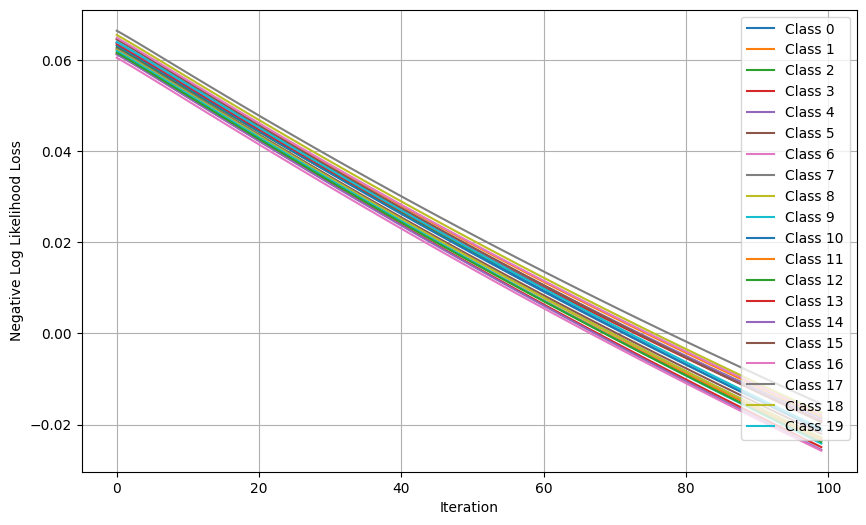

In [18]:
plt.figure(figsize=(10,6))
for i, class_losses in enumerate(GT_dist_losses):
    #print(f'class_losses for class {i}: {class_losses}')
    plt.plot(class_losses, label=f'Class {i}')
#plt.title(title)
plt.xlabel('Iteration')
plt.ylabel('Negative Log Likelihood Loss')
plt.legend()
plt.grid()
plt.show()

<H1>3) Compute classification metrics for training and test data sets</H1>

$\large\quad\text{Use the trained Naive Bayes classifier to make predictions on training and test data.}$<br>


In [19]:
# Predict log probability of class given the distribution, a test sample, and the class priors
def predict_sample(dist, sample, priors):
    # 1) Compute the class conditional probabilities of the sample
    # P(X=x | C=c_k)
    cond_probs = dist.log_prob(sample)
    # 2) Compute the joint likelihood
    # P(C=c_k, X=x) = P(C=c_k) * P(X=x | C=c_k) = log(P(C=c_k)) + log(P(X=x | C=c_k))
    #print('Type(cond_probs):', type(cond_probs))
    #print('Type priors:', type(tf.cast(priors, dtype=tf.float64)))
    joint_likelihood = tf.math.add(tf.squeeze(tf.math.log(priors)), tf.squeeze(tf.cast(cond_probs, dtype=tf.float64)))
    # 3) Compute a normalization factor
    norm_factor = tf.math.reduce_logsumexp(joint_likelihood, axis=-1, keepdims=True)
    # 4) Normalise the joint likelihood and returns the log prob
    log_prob = joint_likelihood - norm_factor
    # Compute the predicted class
    y_preds = np.argmax(log_prob, axis=-1)
    return log_prob, y_preds

$\large\quad\text{Compute the One Vs. many F1 score for each class.}$<br>
$$\large\text{Precision}\left(\text{class}=k\right)=\frac{\text{TP}\left(\text{class =}k\right)}{\text{TP}\left(\text{class =}k\right)+\text{FP}\left(\text{class =}k\right)}$$
$$\large\text{Recall}\left(\text{class}=k\right)=\frac{\text{TP}\left(\text{class =}k\right)}{\text{TP}\left(\text{class =}k\right)+\text{FN}\left(\text{class =}k\right)}$$
$$\large\text{F-1 Score}\left(\text{class=}k\right)=\frac{2\text{xPrecision}\left(\text{class =}k\right)\text{x Recall}\left(\text{class =}k\right)}{\text{Precision}\left(\text{class =}k\right)\text{+ Recall}\left(\text{class =}k\right)}$$

In [20]:
# Compare the two results
for dist in [GT_dist]:
    # FOR TRAINING SET
    # Create an empty list to store the training probabilities
    training_probabilities = []
    # Create an empty list to store the training predictions
    training_preds = []
    # For each observation of an article in the training set
    for observation, label in zip(train_data, train_labels):
        training_sample_probabilities, training_sample_preds = predict_sample(dist, observation, priors)
        training_probabilities.append(training_sample_probabilities)
        training_preds.append(training_sample_preds)
    # Convert the list of probabilities to a numpy array
    training_probabilities = np.asarray(training_probabilities)
    training_predicted_classes = np.argmax(training_probabilities, axis =-1)
    # Print the one vs many F1 scores for each class for the training set
    # print('Training set F1: ', f1_score(train_labels, training_preds, average=None))
    
    # FOR TESTING SET
    # Create an empty list to store the testing probabilities
    testing_probabilities = []
    # Create an empty list to store the testing predictions
    testing_preds = []
    for observation, label in zip(test_data, test_labels):
        testing_sample_probabilities, testing_sample_preds = predict_sample(dist, observation, priors)
        testing_probabilities.append(testing_sample_probabilities)
        testing_preds.append(testing_sample_preds)
    # Convert the list of probabilities to a numpy array
    testing_probabilities = np.asarray(testing_probabilities)
    testing_predicted_classes = np.argmax(testing_probabilities, axis =-1)
    # Print the one vs many F1 scores for each class for the testing set
    # print('Test set F1: ', f1_score(test_labels, testing_preds, average=None))

$\large\quad\text{Plot the  per-class one vs. many F1 scores for the training and test sets.}$<br>

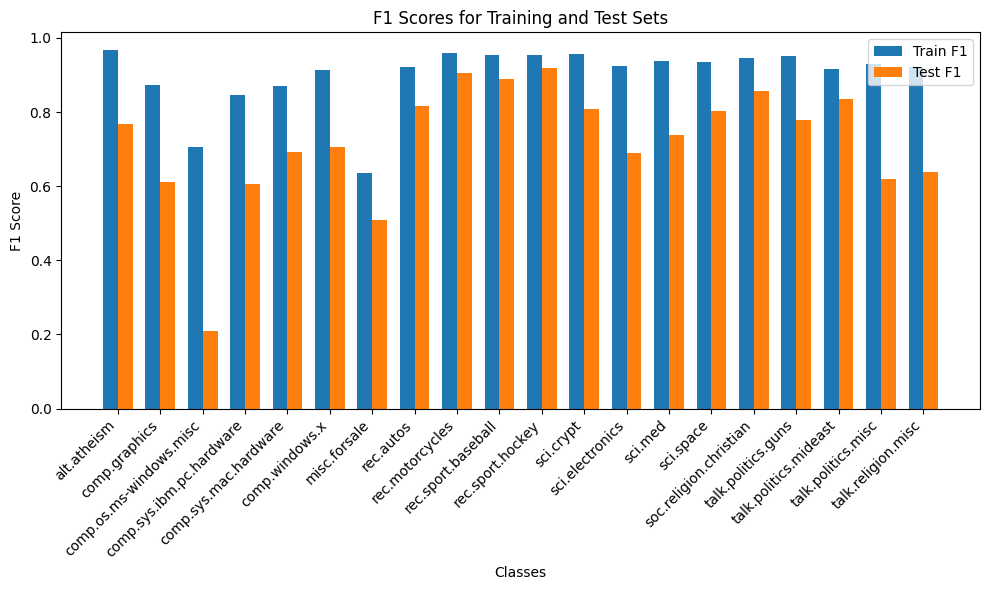

In [21]:
# Bar plot the F1 scores for each class in training and test sets
plt.figure(figsize=(10,6))
f1_train = f1_score(train_labels, training_preds, average=None)
f1_test = f1_score(test_labels, testing_preds, average=None)
x = np.arange(len(categories))  # the label locations
width = 0.35  # the width of the bars
# Plotting the bars for training and test F1 scores
plt.bar(x - width/2, f1_train, width, label='Train F1')
plt.bar(x + width/2, f1_test, width, label='Test F1')
plt.xlabel('Classes')
plt.ylabel('F1 Score')
plt.title('F1 Scores for Training and Test Sets')
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()